In [2]:
words = open('names.txt', 'r').read().splitlines()

In [3]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [4]:
min(len(w) for w in words)

2

In [5]:
max(len(w) for w in words)

15

In [6]:
b = {}
for w in words[:3]:
    chs = ['<S>']+list(w) +['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):  #chs-><S> chs[1:]-><e>
        bigram = (ch1,ch2)
        b[bigram] = b.get(bigram, 0) +1 #.get returns count if none return 0 and add 1 regardless 
        print(ch1,ch2)

<S> e
e m
m m
m a
a <E>
<S> o
o l
l i
i v
v i
i a
a <E>
<S> a
a v
v a
a <E>


In [7]:
b

{('<S>', 'e'): 1,
 ('e', 'm'): 1,
 ('m', 'm'): 1,
 ('m', 'a'): 1,
 ('a', '<E>'): 3,
 ('<S>', 'o'): 1,
 ('o', 'l'): 1,
 ('l', 'i'): 1,
 ('i', 'v'): 1,
 ('v', 'i'): 1,
 ('i', 'a'): 1,
 ('<S>', 'a'): 1,
 ('a', 'v'): 1,
 ('v', 'a'): 1}

In [8]:
import torch


In [9]:
N=torch.zeros((28,28), dtype=torch.int32)  #26 char + 2 special chars

In [10]:
N[1,3] +=1

In [11]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i for i,s in enumerate(chars)} #integer index and actual element of the list-enumerate-->mapping char to integer
stoi['<S>'] = 26
stoi['<E>'] = 27

In [12]:
stoi

{'a': 0,
 'b': 1,
 'c': 2,
 'd': 3,
 'e': 4,
 'f': 5,
 'g': 6,
 'h': 7,
 'i': 8,
 'j': 9,
 'k': 10,
 'l': 11,
 'm': 12,
 'n': 13,
 'o': 14,
 'p': 15,
 'q': 16,
 'r': 17,
 's': 18,
 't': 19,
 'u': 20,
 'v': 21,
 'w': 22,
 'x': 23,
 'y': 24,
 'z': 25,
 '<S>': 26,
 '<E>': 27}

In [13]:
for w in words:
    chs = ['<S>']+list(w) +['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):  #chs-><S> chs[1:]-><e>
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1,ix2] +=1
        bigram = (ch1,ch2)
        b[bigram] = b.get(bigram, 0) +1 #.get returns count if none return 0 and add 1 regardless 
        # print(ch1,ch2)

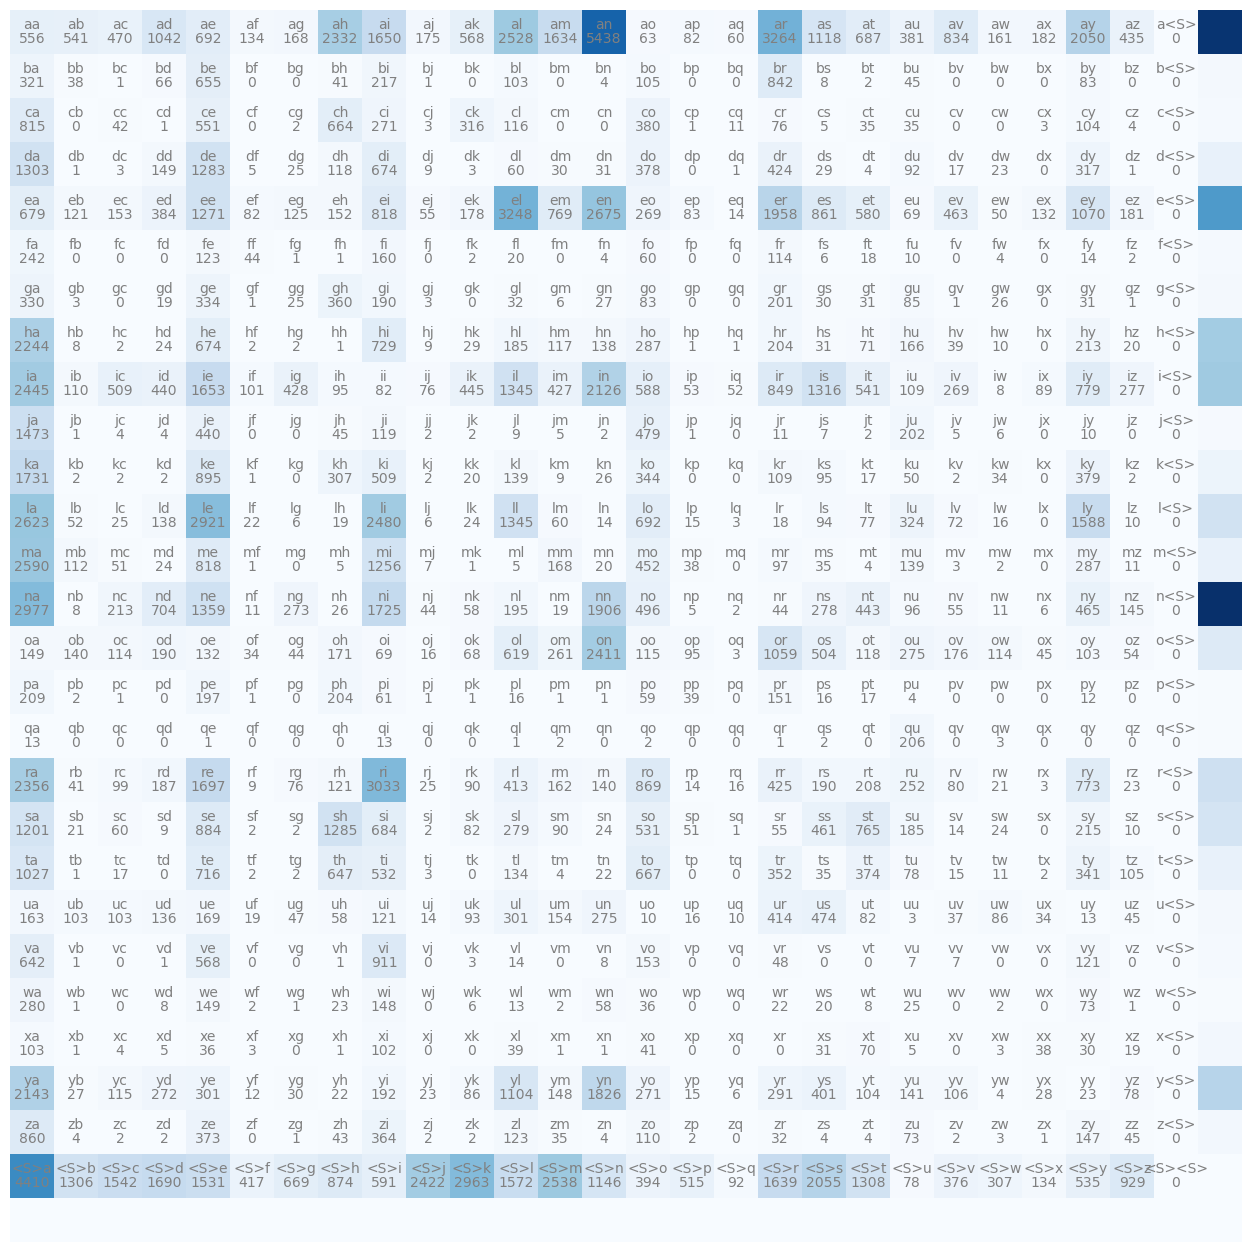

In [14]:
import matplotlib.pyplot as plt
%matplotlib inline
itos = {i:s for s,i in stoi.items()}
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');


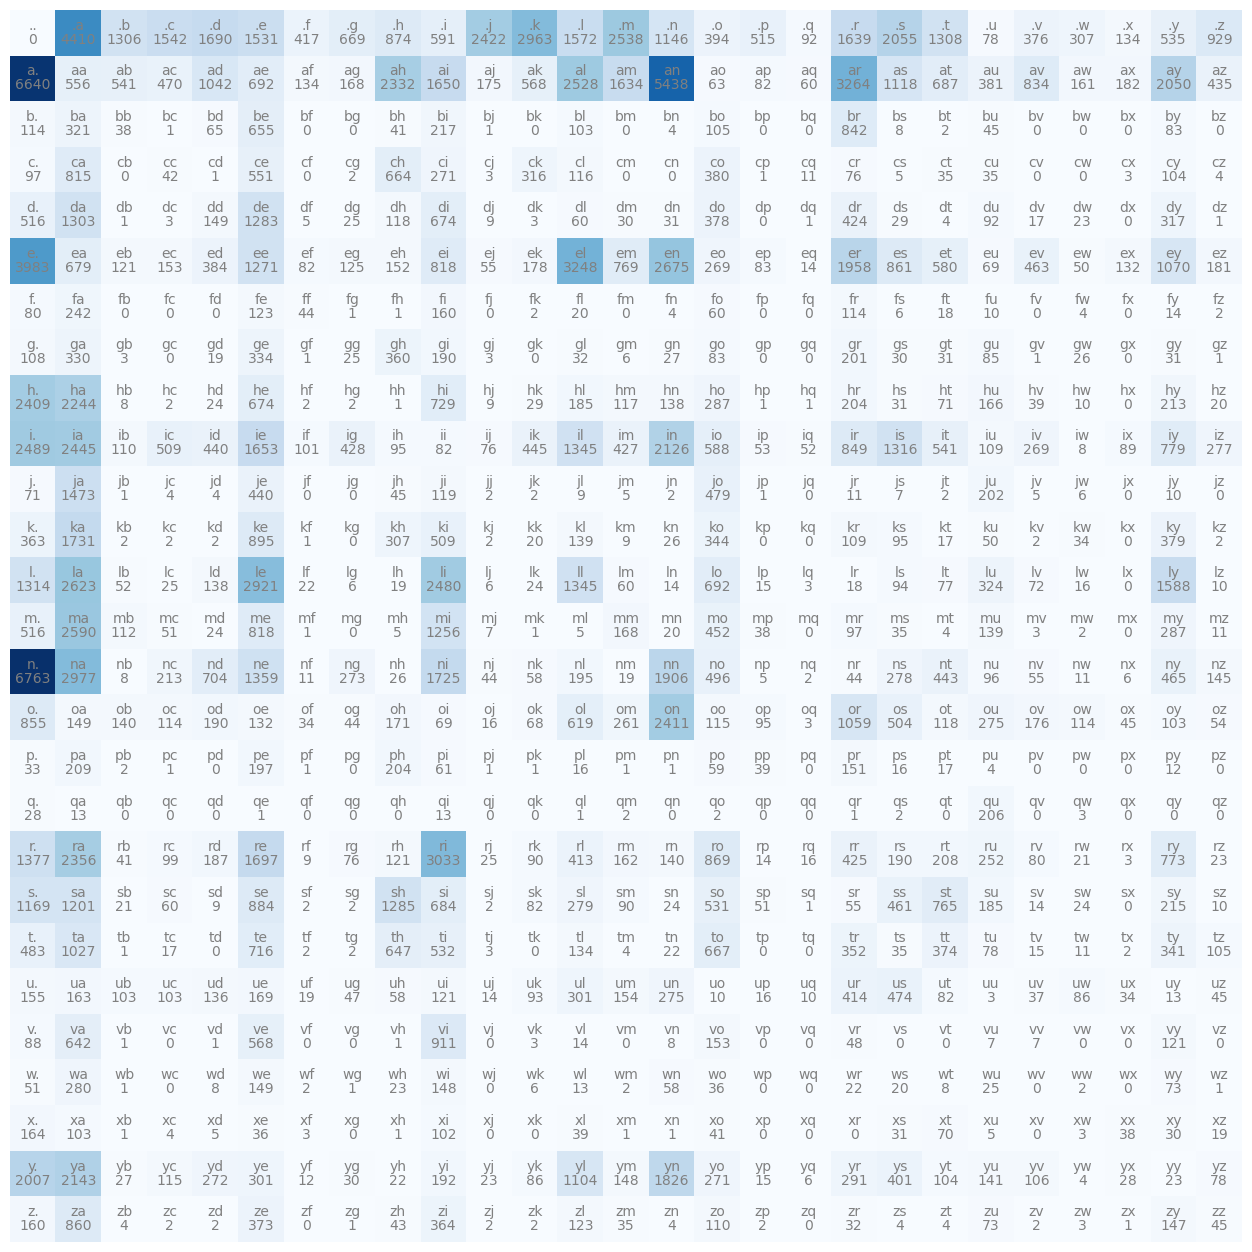

In [15]:
import matplotlib.pyplot as plt
%matplotlib inline
N=torch.zeros((27,27), dtype=torch.int32)  #26 char + 1 special chars
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)} #integer index and actual element of the list-enumerate-->mapping char to integer(first char is . so start from index 1)
stoi['.'] = 0
for w in words:
    chs = ['.']+list(w) +['.']
    for ch1, ch2 in zip(chs, chs[1:]):  #chs-><S> chs[1:]-><e>
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1,ix2] +=1
        bigram = (ch1,ch2)
        b[bigram] = b.get(bigram, 0) +1 #.get returns count if none return 0 and add 1 regardless 
        # print(ch1,ch2)


itos = {i:s for s,i in stoi.items()}
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');


In [16]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [17]:
g = torch.Generator().manual_seed(2147483647) #lock the randomness
p = torch.rand(3, generator=g) #for 3 numbers usin above generator
p = p / p.sum() # get probability p/sum of p
p
#tensor([0.6064, 0.3033, 0.0903]) 60% of the samples to be 0, 30% to be 1, 3 times less 2's

tensor([0.6064, 0.3033, 0.0903])

In [18]:
torch.multinomial(p, num_samples=100, replacement=True, generator=g) #generate samples from given probability allowing replacement i.e element to be considered again

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 2, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
        0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 1, 0,
        0, 1, 1, 1])

In [19]:

g = torch.Generator().manual_seed(2147483647)
P = (N+1).float()
P /= P.sum(1, keepdims=True)
for i in range(10):
  
  out = []
  ix = 0
  while True:
    p = P[ix]
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))


cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.


In [20]:
#likelihood=>product of all probs
log_likelihood = 0.0
n = 0

for w in words:
#for w in ["andrejq"]:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]
    logprob = torch.log(prob)
    log_likelihood += logprob
    n += 1
    #print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

log_likelihood=tensor(-559951.5625)
nll=tensor(559951.5625)
2.4543561935424805


In [23]:
xs, ys = [],[]
for w in words[:1]:
    chs = ['.']+list(w) +['.']
    for ch1, ch2 in zip(chs, chs[1:]):  #chs-><S> chs[1:]-><e>
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        print(ch1, ch2)
        xs.append(ix1)
        ys.append(ix2)


. e
e m
m m
m a
a .


In [35]:
xs
# ys

tensor([ 0,  5, 13, 13,  1])

In [40]:
import torch.nn.functional as F
xs=torch.tensor(xs)
ys=torch.tensor(ys)
xenc =F.one_hot(xs, num_classes=27).float()
xenc

/var/folders/kz/6r02gh717z72bnrsjszfd2f80000gn/T/ipykernel_55604/323022794.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  xs=torch.tensor(xs)
/var/folders/kz/6r02gh717z72bnrsjszfd2f80000gn/T/ipykernel_55604/323022794.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ys=torch.tensor(ys)


tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [41]:
xenc.shape

torch.Size([5, 27])

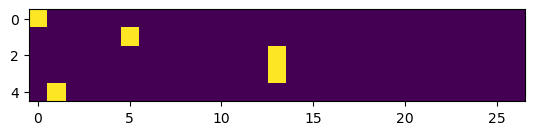

In [42]:
plt.imshow(xenc)
#as we can see 0th, 5th, 13th, 13th, 1st bit are turned on

In [43]:
xenc.dtype

torch.float32

In [44]:
W = torch.randn(27,27) #weights (5,27) * (27,27)-> (5,27)
xenc @ W #multiple with weights (matrix multiplication operator) #for every 1 of 27 neurons we created, what is firing rate of those neurons on every one of those five examples


tensor([[ 2.1456, -0.0404, -0.4598, -0.3053, -0.3815, -0.5410, -0.8801,  1.1321,
         -1.4262, -1.1448,  0.8135,  1.2912, -1.2270,  1.6993, -0.6238, -0.5278,
          2.2298,  0.0653,  0.3398,  1.2012, -0.1627, -0.3775,  0.8906,  1.6663,
         -0.1493,  0.2899, -0.7530],
        [-0.7956,  0.8422, -1.2795, -0.0393,  1.2438,  0.4617,  0.0574,  2.3551,
          0.5341, -2.0255, -0.5081,  0.3158,  0.1807, -0.0656, -0.8562, -0.1984,
          0.6827, -0.3073,  1.4103, -0.4711, -1.3968,  0.0457, -0.6416, -1.1220,
          1.3887, -1.1724, -0.5711],
        [-0.4734,  1.3442,  1.4868, -1.5426, -0.7793, -1.5741,  0.0104, -0.5476,
         -0.7065,  0.9821,  0.8992,  1.2919, -0.0853,  0.6261,  0.2059, -1.3236,
         -1.8463, -1.0492,  0.4246, -0.5906, -0.6636,  1.0606, -1.6302, -0.9139,
         -0.9344, -0.0759,  1.4418],
        [-0.4734,  1.3442,  1.4868, -1.5426, -0.7793, -1.5741,  0.0104, -0.5476,
         -0.7065,  0.9821,  0.8992,  1.2919, -0.0853,  0.6261,  0.2059, -1.3236

In [46]:
(xenc @W) [3,13] # firing rate of 13th neuron looking at 3rd input

tensor(0.6261)

In [47]:
logits = (xenc @W)
counts = logits.exp()
probs = counts/counts.sum(1, keepdims=True)
probs

tensor([[0.1526, 0.0171, 0.0113, 0.0132, 0.0122, 0.0104, 0.0074, 0.0554, 0.0043,
         0.0057, 0.0403, 0.0649, 0.0052, 0.0976, 0.0096, 0.0105, 0.1660, 0.0191,
         0.0251, 0.0593, 0.0152, 0.0122, 0.0435, 0.0945, 0.0154, 0.0239, 0.0084],
        [0.0107, 0.0548, 0.0066, 0.0227, 0.0820, 0.0375, 0.0250, 0.2490, 0.0403,
         0.0031, 0.0142, 0.0324, 0.0283, 0.0221, 0.0100, 0.0194, 0.0468, 0.0174,
         0.0968, 0.0148, 0.0058, 0.0247, 0.0124, 0.0077, 0.0947, 0.0073, 0.0133],
        [0.0168, 0.1036, 0.1194, 0.0058, 0.0124, 0.0056, 0.0273, 0.0156, 0.0133,
         0.0721, 0.0664, 0.0983, 0.0248, 0.0505, 0.0332, 0.0072, 0.0043, 0.0095,
         0.0413, 0.0150, 0.0139, 0.0780, 0.0053, 0.0108, 0.0106, 0.0250, 0.1142],
        [0.0168, 0.1036, 0.1194, 0.0058, 0.0124, 0.0056, 0.0273, 0.0156, 0.0133,
         0.0721, 0.0664, 0.0983, 0.0248, 0.0505, 0.0332, 0.0072, 0.0043, 0.0095,
         0.0413, 0.0150, 0.0139, 0.0780, 0.0053, 0.0108, 0.0106, 0.0250, 0.1142],
        [0.0524, 0.0997,

In [48]:
probs[0]

tensor([0.1526, 0.0171, 0.0113, 0.0132, 0.0122, 0.0104, 0.0074, 0.0554, 0.0043,
        0.0057, 0.0403, 0.0649, 0.0052, 0.0976, 0.0096, 0.0105, 0.1660, 0.0191,
        0.0251, 0.0593, 0.0152, 0.0122, 0.0435, 0.0945, 0.0154, 0.0239, 0.0084])

In [49]:
xs

tensor([ 0,  5, 13, 13,  1])

In [50]:
ys

tensor([ 5, 13, 13,  1,  0])

In [51]:

# randomly initialize 27 neurons' weights. each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g)
xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
logits = xenc @ W # predict log-counts
counts = logits.exp() # counts, equivalent to N
probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
# btw: the last 2 lines here are together called a 'softmax'

In [52]:
probs.shape

torch.Size([5, 27])

In [53]:
nlls = torch.zeros(5)
for i in range(5):
  # i-th bigram:
  x = xs[i].item() # input character index
  y = ys[i].item() # label character index
  print('--------')
  print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
  print('input to the neural net:', x)
  print('output probabilities from the neural net:', probs[i])
  print('label (actual next character):', y)
  p = probs[i, y]
  print('probability assigned by the net to the the correct character:', p.item())
  logp = torch.log(p)
  print('log likelihood:', logp.item())
  nll = -logp
  print('negative log likelihood:', nll.item())
  nlls[i] = nll

print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

--------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459])
label (actual next character): 5
probability assigned by the net to the the correct character: 0.012286250479519367
log likelihood: -4.3992743492126465
negative log likelihood: 4.3992743492126465
--------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
        0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
        0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472])
label (actual next character): 13
probability assigned by the net to the the correct character:

In [ ]:
# --------- !!! OPTIMIZATION !!!  --------------

In [54]:
ys

tensor([ 5, 13, 13,  1,  0])

In [55]:
probs[0,5], probs[1,13], probs[2,13], probs[3,1], probs[4,0]

(tensor(0.0123),
 tensor(0.0181),
 tensor(0.0267),
 tensor(0.0737),
 tensor(0.0150))

In [62]:
probs[torch.arange(5),ys] #probs matching with output vals
loss = -probs[torch.arange(5),ys].log().mean()

tensor([0.0123, 0.0181, 0.0267, 0.0737, 0.0150], grad_fn=<IndexBackward0>)

In [60]:
# random 27 neurons' weights. each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)
# forward pass
xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
logits = xenc @ W # predict log-counts
counts = logits.exp() # counts, equivalent to N
probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
loss = -probs[torch.arange(5), ys].log().mean()

In [64]:
print(loss.item())
# backward pass
W.grad = None # set to zero the gradient
loss.backward()
W.data += -0.1 * W.grad

3.7693049907684326


In [ ]:
#optimization again

In [69]:
W.grad[:1]

tensor([[ 0.0121,  0.0020,  0.0025,  0.0008,  0.0034, -0.1975,  0.0005,  0.0046,
          0.0027,  0.0063,  0.0016,  0.0056,  0.0018,  0.0016,  0.0100,  0.0476,
          0.0121,  0.0005,  0.0050,  0.0011,  0.0068,  0.0022,  0.0006,  0.0040,
          0.0024,  0.0307,  0.0292]])

In [70]:
# prep dataset
xs, ys = [], []
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

number of examples:  228146


In [71]:
# gradient descent
for k in range(1):
  
  # forward pass
  xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
  logits = xenc @ W # predict log-counts
  counts = logits.exp() # counts, equivalent to N
  probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
  loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()  #regularization: make W's near 0(converge) to reduce loss
  print(loss.item())
  
  # backward pass
  W.grad = None # set to zero the gradient
  loss.backward()
  
  # update
  W.data += -50 * W.grad

3.76861834526062


In [72]:
# finally, sample from the 'neural net' model
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
  
  out = []
  ix = 0
  while True:
    

    # BEFORE:
    #p = P[ix]

    # NOW:
    xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum(1, keepdims=True) # probabilities for next character
    # ----------
    
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

texzmkloglquszipczktxhkmpmzistttwinmlgdukzka.
zr.
rocxtpucjwtsc.
gmtokmxczisqytxugkwpt.
dajkkluydjmscdgu.
